## Seasonality

In [1]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches

In [ ]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=3, memory_limit=15e9)
client

In [ ]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

In [ ]:
ssh = xr.open_dataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/SSH_1993-01c.nc')
ssh = ssh.compute()

In [ ]:
# U = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U*.nc',chunks = {'time_counter':1}).isel(deptht=slice(0,7))
# U=U.chunk({'time_counter': 5, 'deptht': 7, 'y': 250, 'x': 600}).rename({'vozocrtx': 'U'})
U = xr.open_mfdataset(
    '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U*.nc',
    chunks={'time_counter':-1, 'deptht': 7, 'y': 250, 'x': 600},
).isel(deptht=slice(0, 7))
U = U.rename({"vozocrtx": "U"})
U

In [ ]:
# V = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/V*.nc',chunks = {'time_counter':1}).isel(deptht=slice(0,7))
# V=V.chunk({'time_counter': 5, 'deptht': 7, 'y': 250, 'x': 600}).rename({'vomecrty':'V'})
# V
V = xr.open_mfdataset(
    '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/V*.nc',
    chunks={'time_counter':-1, 'deptht': 7, 'y': 250, 'x': 600},
).isel(deptht=slice(0, 7))
V = V.rename({"vomecrty": "V"})
V

In [ ]:
U_T = (U.U.shift(x=1) + U.U)*0.5

V_T = (V.V.shift(y=1) + V.V)*0.5

In [ ]:
UV = xr.Dataset(
    data_vars={
        'U': (('time','depth','lat','lon'), U_T.data),
        'V': (('time','depth','lat', 'lon'), V_T.data),
    },
    coords={
        'time':U_T.time_counter.data,
        'depth':U_T.deptht.data,
        'lat':ssh.nav_lat.isel(x=0).data,
        'lon':ssh.nav_lon.isel(y=0).data,
    }
)
# UV['UV'] = (UV.U**2+UV.V**2)**0.5
# UV = UV.persist()
UV

#### Monthly anomalies

In [ ]:
def monthly_anom(data):
    # 1) daily -> monthly mean (one value per month)
    mon = data.resample(time="MS").mean()   # "MS" = month start; use "M" for month end

    # 2) monthly climatology (12-month seasonal cycle)
    clim = mon.groupby("time.month").mean("time")

    # 3) anomalies
    anom = mon.groupby("time.month") - clim
    return anom
    
# def monthly_anom(data):    
#     season = data.groupby('time.month').mean(dim='time')
#     anom = data.groupby('time.month') - season
#     return anom

In [ ]:
monthly_anom(UV).resample(time="MS").mean().drop_encoding().to_netcdf('UV_anom.nc')

In [ ]:
# UV.isel(time=0).load()

# rms_speed = ((UV.U.isel(time=slice(0,2))**2 + UV.V.isel(time=slice(0,2))**2).mean('time'))**0.5 
# rms_speed.load().mean('depth').plot(robust=True)

In [ ]:
uv = UV.UV.mean(dim='depth')
uv = uv.chunk({'time': 20, 'lat': -1, 'lon':-1})
uv=uv.persist()
uv
# uv.isel(time=0).load().plot()
# uv.drop_encoding().to_netcdf('UV_all_time.nc')
# uv.to_netcdf('UV_all_time.nc')

In [2]:
UV_mean = xr.open_dataset('UV_0_7m.nc')
UV_mean

<xarray.Dataset> Size: 20GB
Dimensions:  (time: 7973, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    UV       (time, lat, lon) float32 20GB ...

In [3]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

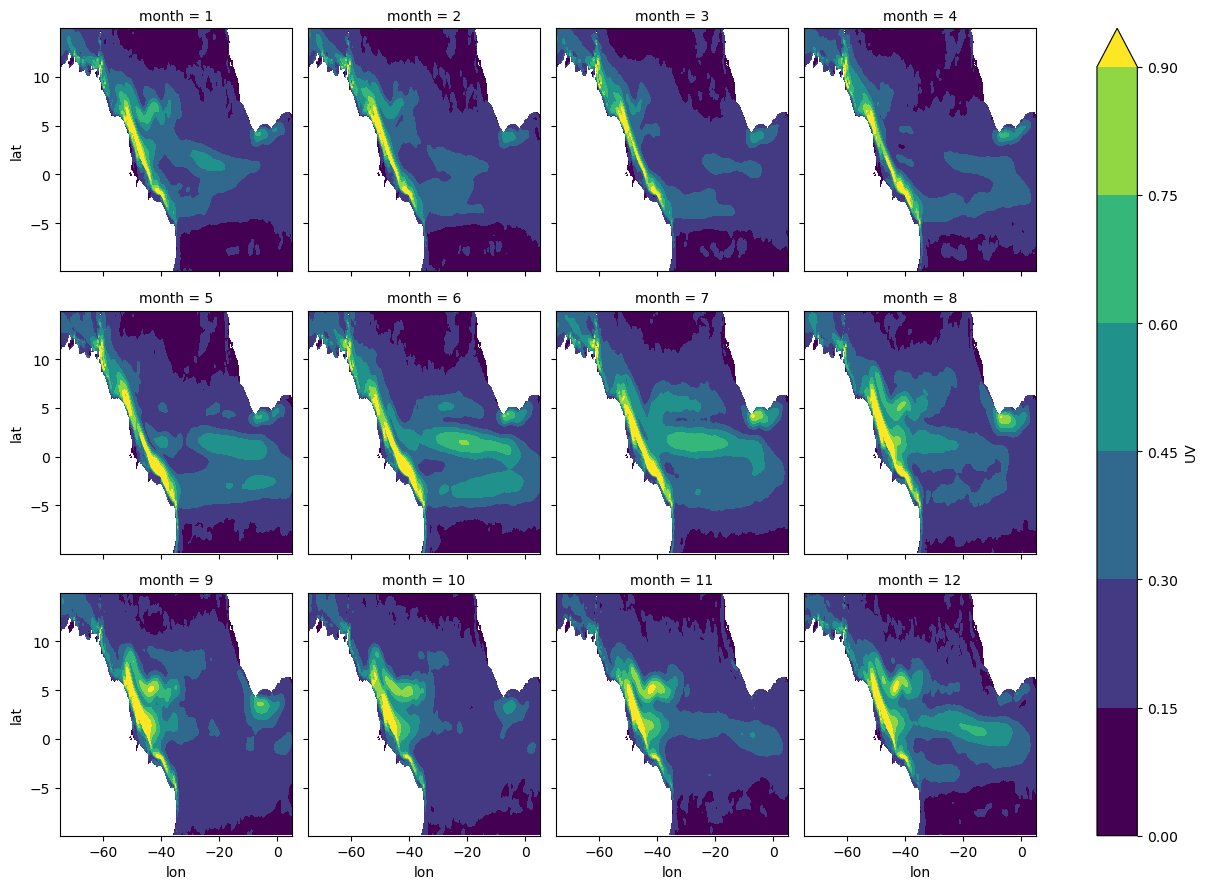

In [4]:
seasonality(UV_mean).UV.sel(lon=slice(-75,5),lat=slice(-10,15)).plot.contourf(x="lon", y="lat", col="month", col_wrap=4,robust=True)

In [5]:
def _std_(data):    
    time_std = data.groupby('time.month').std(dim='time')
    return time_std

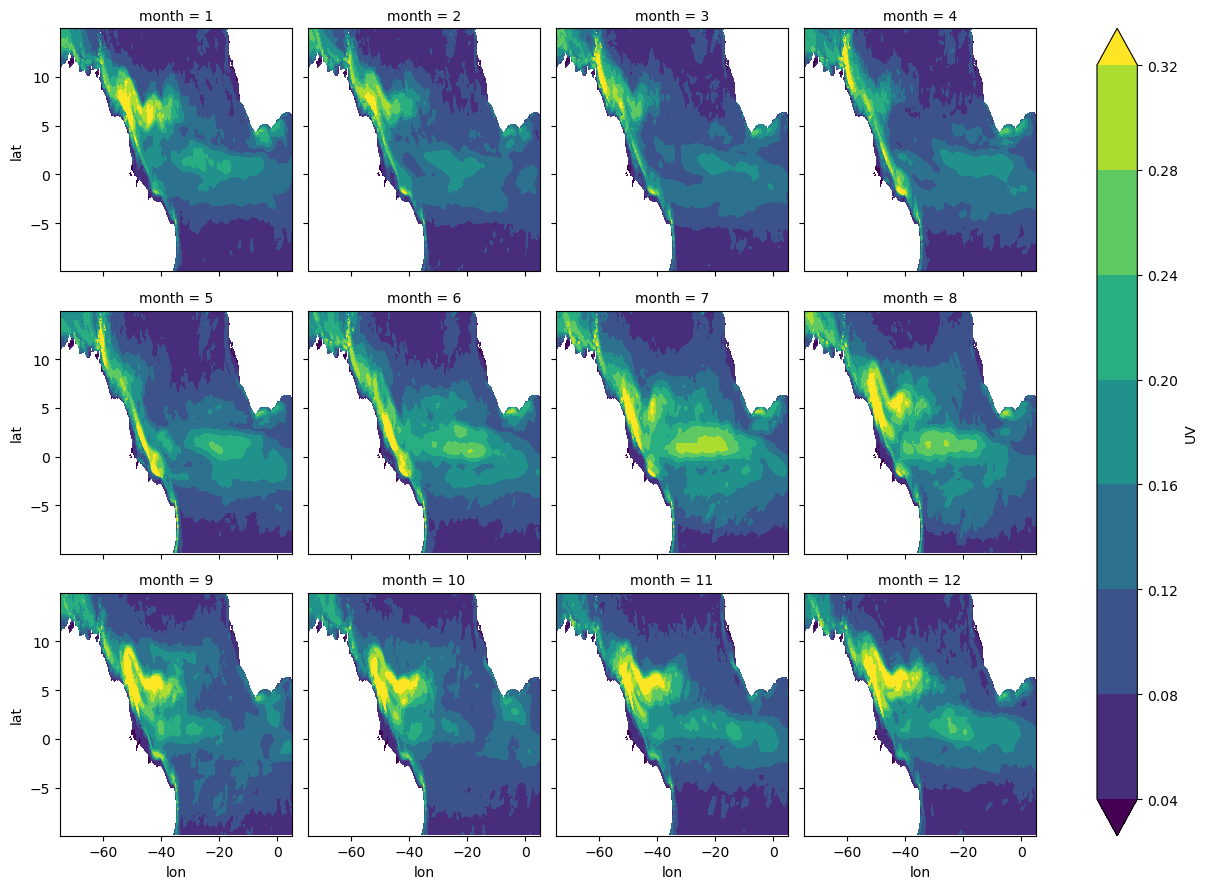

In [6]:
_std_(UV_mean).UV.sel(lon=slice(-75,5),lat=slice(-10,15)).plot.contourf(x="lon", y="lat", col="month", col_wrap=4,robust=True)